Figure S12: Distribution of single-gene log2aFC effects. A Maximum PIP-weighted | log2aFC | for any gene in a cluster, split by if the QTL is discovered as both a pcQTL and eQTL, an eQTL only, or a pcQTL only. Maximum | log2aFC | for credible sets discovered as pcQTLs only or eQTLs only are not significantly different (p=0.333) from each other. Maximum | log2aFC | for credible sets discovered as both pcQTLs and eQTLs are significantly higher than those discovered as pcQTLs only (p<10-10) or eQTLs only (<10-10). P-values from Mann-Whitney U test. B The distance from the lead variant of the QTL credible set to the TSS of the gene with the second largest  | log2aFC |  vs the distance from the lead variant to the TSS of the gene with the largest  | log2aFC |  gene. C Annotation enrichments for PIP-weighted variant effect predictor categories for QTL credible sets split by if the CV of PIP-weighted  | log2aFC |  is higher or lower than 0.8. D The second largest PIP-weighted | log2aFC | for each QTL on any eGene in a cluster vs the largest PIP-weighted | log2aFC | on any eGene in a cluster, split by if the QTL is discovered as both a pcQTL and eQTL, an eQTL only, or a pcQTL only.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns 
import ast

from tqdm.auto import tqdm 
tqdm.pandas()

prefix = '/home/klawren/oak/pcqtls'
import yaml
config_path= f'{prefix}/config_old/main_pcqtl.yaml'
with open(config_path, 'r') as f:
    config = yaml.safe_load(f)

import sys
sys.path.append('/home/klawren/oak/pcqtls/workflow/scripts')
from utils import *
from annotate_clusters import * 

%config InlineBackend.figure_formats = ['png']
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42
plt.rcParams.update({'font.size': 7})

In [2]:
qtl_signal_groups = load_across_tissues(config, load_qtl_signal_groups)
qtl_signal_groups['qtl_group_label'] = np.where((qtl_signal_groups['num_e_coloc'] > 0), np.where((qtl_signal_groups['num_pc_coloc'] > 0), 'Both', 'eQTL only'), 'pcQTL only')

eqtl_susie = load_across_tissues(config, load_e_susie)
pcqtl_susie = load_across_tissues(config, load_pc_susie)

pcqtl_afc = load_across_tissues(config, load_pc_afc)
eqqtl_afc = load_across_tissues(config, load_e_afc)
qtl_afc = pd.concat([pcqtl_afc, eqqtl_afc]).drop_duplicates(['tissue_id', 'pid', 'sid']).reset_index(drop=True)

pcqtl_susie['cluster_id'] = pcqtl_susie['phenotype_id'].str.split('_pc').str[0]
pcqtl_susie['gene_id'] = pcqtl_susie['cluster_id'].str.split('_')

eqtl_susie['cluster_id'] = eqtl_susie['phenotype_id'].str.split('_e').str[0]
eqtl_susie['gene_id'] = eqtl_susie['cluster_id'].str.split('_')

susie = pd.concat([pcqtl_susie, eqtl_susie], keys=['pcQTL', 'eQTL'], names=['qtl_type']).reset_index()

In [3]:
# Load GENCODE annotations
gid_gencode = pd.read_table(f"{config['working_dir']}/{config["gencode_path"]}").set_index('gene_id')
gid_gencode['tss_pos'] = gid_gencode['tss_pos'].apply(literal_eval)

# add lead variant information, max pip per phenotype-tissue-cs id group
lead_variant_idx = susie.groupby(['phenotype_id', 'tissue_id', 'cs_id'])['pip'].idxmax()
lead_variant_map = susie.loc[lead_variant_idx, ['phenotype_id', 'tissue_id', 'cs_id', 'variant_id']].set_index(['phenotype_id', 'tissue_id', 'cs_id'])['variant_id']
susie['lead_variant_id'] = susie.set_index(['phenotype_id', 'tissue_id', 'cs_id']).index.map(lead_variant_map)
susie['lead_variant_position'] = susie['lead_variant_id'].str.split('_').str[1].astype(int)
susie_explode = susie.explode('gene_id')

tss_merged_susie = pd.merge(susie_explode, gid_gencode.explode('tss_pos'), left_on='gene_id', right_on='gene_id', how='left')
tss_merged_susie['lead_var_tss_dist'] = np.where(tss_merged_susie['strand'] == '+', 
                tss_merged_susie['lead_variant_position'] - tss_merged_susie['tss_pos'], 
                tss_merged_susie['tss_pos'] - tss_merged_susie['lead_variant_position'])

lead_var_tss_dist = tss_merged_susie.groupby(['phenotype_id', 'cs_id', 'tissue_id', 'gene_id']).agg(
    lead_var_tss_dist=('lead_var_tss_dist', 'min')).reset_index()

In [4]:
# merge in afc information
susie_explode_afc = pd.merge(susie_explode, qtl_afc[['pid', 'sid', 'tissue_id', 'log2_aFC']], left_on=['gene_id', 'variant_id', 'tissue_id'], 
    right_on=['pid', 'sid', 'tissue_id'], how='left')

# pip-weighted afc over credible set
susie_explode_afc['pip_afc'] = susie_explode_afc['pip'] * susie_explode_afc['log2_aFC']
credible_set_grouped_afc = susie_explode_afc.groupby(['phenotype_id', 'cs_id', 'tissue_id', 'gene_id', 'qtl_type']).agg({'pip_afc':'sum', 'pip':'sum'}).reset_index()
credible_set_grouped_afc['pip_afc_weighted'] = credible_set_grouped_afc['pip_afc']/credible_set_grouped_afc['pip']
credible_set_grouped_afc['abs_pip_afc_weighted'] = credible_set_grouped_afc['pip_afc_weighted'].abs()

# add in lead var distances
credible_set_grouped_afc = pd.merge(credible_set_grouped_afc, lead_var_tss_dist, on=['phenotype_id', 'cs_id', 'tissue_id', 'gene_id'], how='left')
credible_set_grouped_afc['lead_var_tss_dist'] = credible_set_grouped_afc['lead_var_tss_dist'].abs()

In [5]:
# For each group of tissue-phenotype-cs, get the rows with the largest and second largest absolute pip-weighted afc,
# and extract both the values and the corresponding distances

def get_top2_afc_and_dist(df):
    # Sort by absolute pip-weighted afc descending
    sorted_df = df.sort_values('abs_pip_afc_weighted', ascending=False)
    # Get largest and second largest rows
    top1 = sorted_df.iloc[0]
    top2 = sorted_df.iloc[1] if len(sorted_df) > 1 else top1
    return pd.Series({
        'max_abs_pip_afc_weighted': top1['abs_pip_afc_weighted'],
        'second_abs_pip_afc_weighted': top2['abs_pip_afc_weighted'],
        'distance_first': top1['lead_var_tss_dist'],
        'distance_second': top2['lead_var_tss_dist']
    })

afc_dist_summary = credible_set_grouped_afc.groupby(['tissue_id', 'phenotype_id', 'cs_id']).progress_apply(get_top2_afc_and_dist).reset_index()

  0%|          | 0/37315 [00:00<?, ?it/s]

/home/klawren/.pixi/envs/python/lib/python3.12/site-packages/tqdm/std.py:917: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return getattr(df, df_function)(wrapper, **kwargs)


In [6]:
# add in labels about pcqtl vs eqtl vs both
qtl_signal_groups['cs_phenotype_id'] = qtl_signal_groups['signal_id'].str.split('-')
afc_dist_summary['cs_phenotype_id'] = afc_dist_summary['phenotype_id'] + '_cs_' + afc_dist_summary['cs_id'].astype(str)
cluster_grouped_afc = pd.merge(afc_dist_summary, qtl_signal_groups.explode('cs_phenotype_id'), on=['tissue_id', 'cs_phenotype_id'], how='left')

In [7]:
# load in vep annotations
susie_annotated = load_across_tissues(config, load_susie_annotated)

# format the egene info to be a list instead of a string
susie_annotated = susie_annotated[~(susie_annotated['egene_id_list'] == '[nan]')]
susie_annotated['egene_qtl_slope'] = susie_annotated['egene_qtl_slope'].apply(ast.literal_eval)
susie_annotated['egene_id_list'] = susie_annotated['egene_id_list'].apply(ast.literal_eval)

# explode to egenes
susie_annotated_explode = susie_annotated.explode(['egene_qtl_slope', 'egene_id_list'])
susie_annotated_explode['egene_id'] = susie_annotated_explode['egene_id_list']

In [8]:
# add annotation information 
def get_gene_matched_effect(row):
    gene_matched_effect = []
    for vep_effect in row['vep_info'].split(','):
        if row['egene_id'].split('.')[0] in vep_effect:
            gene_matched_effect.append(vep_effect.split('|')[1])
    return list(set(gene_matched_effect))

susie_annotated_explode['vep_info_gene'] = susie_annotated_explode.progress_apply(get_gene_matched_effect, axis=1).astype(str)
# promoter, enahncer, and ctcf are not gene specific
susie_annotated_explode['vep_CTCF'] = susie_annotated_explode['vep_info'].str.contains('CTCF_binding_site').astype(float) * susie_annotated_explode['pip']
susie_annotated_explode['vep_enhancer'] = susie_annotated_explode['vep_info'].str.contains('enhancer').astype(float) * susie_annotated_explode['pip']
susie_annotated_explode['vep_promoter'] = susie_annotated_explode['vep_info'].str.contains('promoter').astype(float) * susie_annotated_explode['pip']
susie_annotated_explode['qtl_in_tad'] = (susie_annotated_explode['qtl_in_tad']) * susie_annotated_explode['pip']
susie_annotated_explode['vep_gene_matched_splice'] = susie_annotated_explode['vep_info_gene'].str.contains('splice', regex=True).astype(float) * susie_annotated_explode['pip']
susie_annotated_explode['vep_gene_matched_nmd'] = susie_annotated_explode['vep_info_gene'].str.contains('stop_gained', regex=True).astype(float) * susie_annotated_explode['pip']
susie_annotated_explode['vep_any_effect'] = (susie_annotated_explode['vep_info_gene'].str.strip("'[],").apply(len) > 0).astype(float) * susie_annotated_explode['pip']
susie_annotated_explode['egene_qtl_slope'] = susie_annotated_explode['egene_qtl_slope'] * susie_annotated_explode['pip']

  0%|          | 0/2482482 [00:00<?, ?it/s]

In [9]:
# group into credible sets, summing over pip weighted effects
cs_grouped = susie_annotated_explode.groupby(['phenotype_id', 'cs_id', 'tissue_id', 'cluster_id' ,'egene_id']).agg(vep_any_effect=('vep_any_effect','sum'),
                                                                                                                  ctcf=('vep_CTCF','sum'),
                                                                                                                  enhancer=('vep_enhancer','sum'),
                                                                                                                  promoter=('vep_promoter','sum'),
                                                                                                                  tad=('qtl_in_tad','sum'),
                                                                                                                  splice=('vep_gene_matched_splice','sum'),
                                                                                                                  nmd=('vep_gene_matched_nmd','sum'),
                                                                                                                  pip_sum=('pip','sum'),
                                                                                                                  type=('type','first'),
                                                                                                                  lead_variant_id=('lead_variant_id','first')
                                                                                                                  )

annotation_columns = cs_grouped.columns[:-3]
for c in annotation_columns:
    cs_grouped[c] = cs_grouped[c] / cs_grouped['pip_sum']
cs_grouped = cs_grouped.reset_index().reset_index()

# add in underlying signal info
cs_grouped['cs_phenotype_id'] = cs_grouped['phenotype_id'] + '_cs_' + cs_grouped['cs_id'].str.split('_cs_').str[-1]
cs_grouped_annotation = pd.merge(cs_grouped, qtl_signal_groups.explode('cs_phenotype_id'), on=['tissue_id', 'cs_phenotype_id'], how='left')

In [10]:
# group over egenes in a cluster                                                      
egene_grouped_annotation = cs_grouped_annotation.groupby(['tissue_id', 'cs_phenotype_id', 'signal_id']).agg(vep_single_gene=('vep_any_effect',lambda values: (sorted(values, reverse=True)[0]>0) & (sorted(values, reverse=True)[1]==0)), 
                                                             vep_multi_gene=('vep_any_effect',lambda values: sorted(values, reverse=True)[1]>0), 
                                                             ctcf=('ctcf',lambda values: max(values)), 
                                                             enhancer=('enhancer',lambda values: max(values)), 
                                                             vep_promoter=('promoter',lambda values: max(values)), 
                                                             tad=('tad',lambda values: max(values)), 
                                                             splice=('splice',lambda values: max(values)), 
                                                             nmd=('nmd',lambda values: max(values)),
                                                             qtl_group_label=('qtl_group_label', 'first'), 
                                                             cluster_id=('cluster_id_x','first'))

# group over genes in a cluster that a credible set impacts
cluster_grouped_afc_cv = credible_set_grouped_afc.groupby(['tissue_id', 'phenotype_id', 'cs_id', 'qtl_type']).agg(
    mean_afc=('abs_pip_afc_weighted', 'mean'), 
    std_afc=('abs_pip_afc_weighted', 'std'), 
    max_afc=('abs_pip_afc_weighted', 'max')).reset_index()

cluster_grouped_afc_cv['cv_afc'] =  cluster_grouped_afc_cv['std_afc'] / cluster_grouped_afc_cv['mean_afc'] * 100

# add in labels about pcqtl vs eqtl vs both
qtl_signal_groups['cs_phenotype_id'] = qtl_signal_groups['signal_id'].str.split('-')
cluster_grouped_afc_cv['cs_phenotype_id'] = cluster_grouped_afc_cv['phenotype_id'] + '_cs_' + cluster_grouped_afc_cv['cs_id'].astype(str)
cluster_grouped_afc_cv = pd.merge(cluster_grouped_afc_cv, qtl_signal_groups.explode('cs_phenotype_id'), on=['tissue_id', 'cs_phenotype_id'], how='left')

# add in cv_afc information
egene_grouped_annotation = pd.merge(egene_grouped_annotation, cluster_grouped_afc_cv.groupby(['signal_id', 'tissue_id']).agg({'cv_afc': 'mean'}), on=['tissue_id', 'signal_id'], how='left')
egene_grouped_annotation['num_genes'] = egene_grouped_annotation['cluster_id'].str.split('_').apply(len)

In [11]:
column_list = ['vep_multi_gene', 'vep_single_gene', 'vep_promoter', 'enhancer', 'tad', 'ctcf', 'splice', 'nmd']

In [12]:
min_group_size = 10
min_expected_freq = 5
column_list = ['vep_multi_gene', 'vep_single_gene', 'vep_promoter', 'enhancer', 'tad', 'ctcf', 'splice', 'nmd']
divider_cv_acf = egene_grouped_annotation['cv_afc'].median()


enrichment = calculate_enrichment_with_covariates(
            egene_grouped_annotation[egene_grouped_annotation['cv_afc']> divider_cv_acf],
            egene_grouped_annotation[egene_grouped_annotation['cv_afc']<= divider_cv_acf],
            column_list,
            covar_cols=['num_genes'],
            min_group_size=min_group_size, min_expected_freq=min_expected_freq
        )

Complete or quasi-complete separation for nmd


Mann-Whitney U test p-values for Panel A (max_abs_pip_afc_weighted):
eQTL only vs pcQTL only: 3.333e-01
eQTL only vs Both: 7.598e-218
pcQTL only vs Both: 5.214e-217


/local/scratch/klawren/slrmtmp.49273183/ipykernel_15642/922576446.py:78: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axC.set_yticklabels(column_labels)


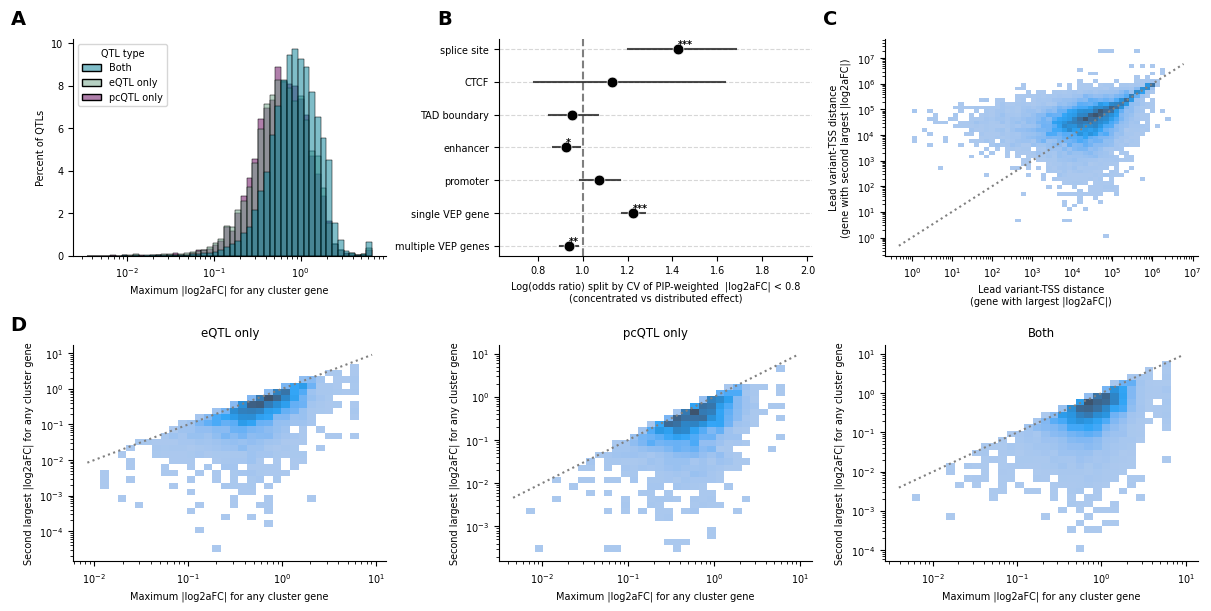

In [36]:
fig, axes = plt.subplots(2, 3, figsize=(12, 6), constrained_layout=True)

# PANEL A: Original AFC histogram, upper left
axA = axes[0,0]
sns.histplot(cluster_grouped_afc, x='max_abs_pip_afc_weighted', hue='qtl_group_label', 
             palette=qtl_palette, bins=50, stat='percent', log_scale=True, common_norm=False, ax=axA)
axA.set_xlabel('Maximum |log2aFC| for any cluster gene')
axA.set_ylabel('Percent of QTLs')
sns.move_legend(axA, "upper left", title='QTL type')
axA.text(-0.15, 1.05, 'A', transform=axA.transAxes, fontsize=14, fontweight='bold', 
           ha='right', va='bottom')
axA.spines[['top', 'right']].set_visible(False)


labels_panel_a = ['eQTL only', 'pcQTL only', 'Both']
data_panel_a = [
    cluster_grouped_afc[cluster_grouped_afc['qtl_group_label'] == label]['max_abs_pip_afc_weighted']
    for label in labels_panel_a
]

print("Mann-Whitney U test p-values for Panel A (max_abs_pip_afc_weighted):")
mw_results = {}
# eQTL only vs pcQTL only
mw_results['eQTL only vs pcQTL only'] = mannwhitneyu(
    data_panel_a[0], data_panel_a[1], alternative='two-sided'
).pvalue
print(f"eQTL only vs pcQTL only: {mw_results['eQTL only vs pcQTL only']:.3e}")
# eQTL only vs Both
mw_results['eQTL only vs Both'] = mannwhitneyu(
    data_panel_a[0], data_panel_a[2], alternative='two-sided'
).pvalue
print(f"eQTL only vs Both: {mw_results['eQTL only vs Both']:.3e}")
# pcQTL only vs Both
mw_results['pcQTL only vs Both'] = mannwhitneyu(
    data_panel_a[1], data_panel_a[2], alternative='two-sided'
).pvalue
print(f"pcQTL only vs Both: {mw_results['pcQTL only vs Both']:.3e}")

# PANEL C (now as panel B): Annotation enrichment (upper center)
axC = axes[0,1]
enrichment_data = enrichment[enrichment['reason'] == 'success'].copy()
enrichment_data = enrichment_data[enrichment_data['annotation'] != 'nmd']  # Remove nmd

y_positions = {annotation: i for i, annotation in enumerate(column_list)}
for i, (idx, row) in enumerate(enrichment.iterrows()):
    y_val = y_positions[row['annotation']]
    axC.scatter(row['odds_ratio'], y_val, 
               color='black', s=60,
               zorder=3, edgecolors='white', linewidth=0.5)
    log_lower_ci = row['ci_lower']
    log_upper_ci = row['ci_upper']

    axC.plot([log_lower_ci, log_upper_ci], [y_val, y_val], 
            color='black', alpha=0.7, linewidth=1.5, zorder=2)
    if pd.notna(row['p_value']):
        if row['p_value'] < 0.001:
            marker = '***'
        elif row['p_value'] < 0.01:
            marker = '**'
        elif row['p_value'] < 0.05:
            marker = '*'
        else:
            marker = ''
        
        if marker:
            axC.text(row['odds_ratio'] , y_val + 0.15, marker, 
                   va='center', color='black', fontweight='bold', zorder=4)
axC.axvline(x=1, color='black', linestyle='--', alpha=0.5, zorder=1)
column_labels = ['', 'multiple VEP genes', 
    'single VEP gene', 
    'promoter', 
    'enhancer', 
    'TAD boundary', 
    'CTCF', 
    'splice site']
axC.set_yticklabels(column_labels)
axC.set_xlabel('Log odds ratio')
axC.spines['top'].set_visible(False)
axC.spines['right'].set_visible(False)
axC.grid(axis='y', linestyle='--', alpha=0.5)
if len(enrichment) > 0:
    log_lower_ci_all = enrichment['ci_lower'].min()
    log_upper_ci_all = enrichment['ci_upper'].max()
    x_margin = 0.2
    axC.set_xlim(log_lower_ci_all * (1 - x_margin), log_upper_ci_all * (1 + x_margin))
axC.set_xlabel('Log(odds ratio) split by CV of PIP-weighted  |log2aFC| < 0.8\n(concentrated vs distributed effect)')
axC.text(-0.15, 1.05, 'B', transform=axC.transAxes, fontsize=14, fontweight='bold', 
         ha='right', va='bottom')

# PANEL B (now as panel C): Distance plot (upper right)
axB = axes[0,2]
sns.histplot(cluster_grouped_afc.groupby('signal_id').first(), 
             x='distance_first', y='distance_second', 
             bins=50, ax=axB, log_scale=True)
axB.plot(axB.get_xlim(), axB.get_xlim(), color='grey', ls=':')
axB.spines[['top', 'right']].set_visible(False)
axB.set_xlabel('Lead variant-TSS distance\n(gene with largest |log2aFC|)')
axB.set_ylabel('Lead variant-TSS distance\n(gene with second largest |log2aFC|)')
axB.text(-0.15, 1.05, 'C', transform=axB.transAxes, fontsize=14, fontweight='bold', 
           ha='right', va='bottom')

# Lower row: D panel for eQTL only, and plots for pcQTL only and Both without E and F labels
labels = ['eQTL only', 'pcQTL only', 'Both']
titles = ['eQTL only', 'pcQTL only', 'Both']
panel_letters = ['D', '', '']  # Only D; E and F will not be labeled

for i, (label, title_text, panel_letter) in enumerate(zip(labels, titles, panel_letters)):
    ax = axes[1, i]
    data = cluster_grouped_afc.groupby('signal_id').first()
    data = data[data['qtl_group_label'] == label]
    sns.histplot(data, x='max_abs_pip_afc_weighted', y='second_abs_pip_afc_weighted', 
                 bins=30, log_scale=(True, True), ax=ax, stat='density')
    ax.plot(ax.get_xlim(), ax.get_xlim(), color='grey', ls=':')
    ax.set_xlabel('Maximum |log2aFC| for any cluster gene')
    ax.set_ylabel('Second largest |log2aFC| for any cluster gene')
    ax.set_title(title_text)
    ax.spines[['top', 'right']].set_visible(False)
    if panel_letter:
        ax.text(-0.15, 1.05, panel_letter, transform=ax.transAxes, fontsize=14, fontweight='bold', 
                ha='right', va='bottom')

plt.savefig(f"{config['working_dir']}/workflow/supplemental_figures/figures/figure_s12.pdf", 
            transparent=True, bbox_inches='tight', dpi=300)
plt.show()